# 08 - Comparativo Final dos Modelos

Reúne os resultados salvos pelos notebooks 04-07 (Regressão Logística, Random Forest, XGBoost e LightGBM) e compara Acurácia, Precision, Recall, AUC Score e tempo de treinamento.

## 1. Importações e Carregamento dos Resultados

In [1]:
import sys
sys.path.append('../src')

import json
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import roc_curve

from preparar_dados import carregar_dados

import warnings
warnings.filterwarnings('ignore')

resultados = []
for caminho in sorted(glob.glob('../models/resultados_*.json')):
    with open(caminho, encoding='utf-8') as f:
        resultados.append(json.load(f))

df_comparativo = pd.DataFrame(resultados).rename(columns={
    'algoritmo': 'Algoritmo',
    'acuracia': 'Acurácia',
    'precision': 'Precision',
    'recall': 'Recall',
    'auc_score': 'AUC Score',
    'tempo_segundos': 'Tempo (segundos)',
})[['Algoritmo', 'Acurácia', 'Precision', 'Recall', 'AUC Score', 'Tempo (segundos)']]

df_comparativo = df_comparativo.sort_values(by='AUC Score', ascending=False).reset_index(drop=True)
df_comparativo


,Algoritmo,Acurácia,Precision,Recall,AUC Score,Tempo (segundos)
0,Random Forest,0.8541,0.4383,0.4412,0.8242,11.4813
1,LightGBM,0.6922,0.2687,0.7969,0.8168,1.0577
2,XGBoost,0.7171,0.2818,0.7623,0.8165,1.8238
3,Regressão Logística (Baseline),0.7028,0.2688,0.7499,0.8020,1.8200


## 2. Tabela Comparativa

In [2]:
print("📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---\n")
print(df_comparativo.to_string(index=False))


📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---

                     Algoritmo  Acurácia  Precision  Recall  AUC Score  Tempo (segundos)
                 Random Forest    0.8541     0.4383  0.4412     0.8242           11.4813
                      LightGBM    0.6922     0.2687  0.7969     0.8168            1.0577
                       XGBoost    0.7171     0.2818  0.7623     0.8165            1.8238
Regressão Logística (Baseline)    0.7028     0.2688  0.7499     0.8020            1.8200


## 3. Gráfico Comparativo de Métricas

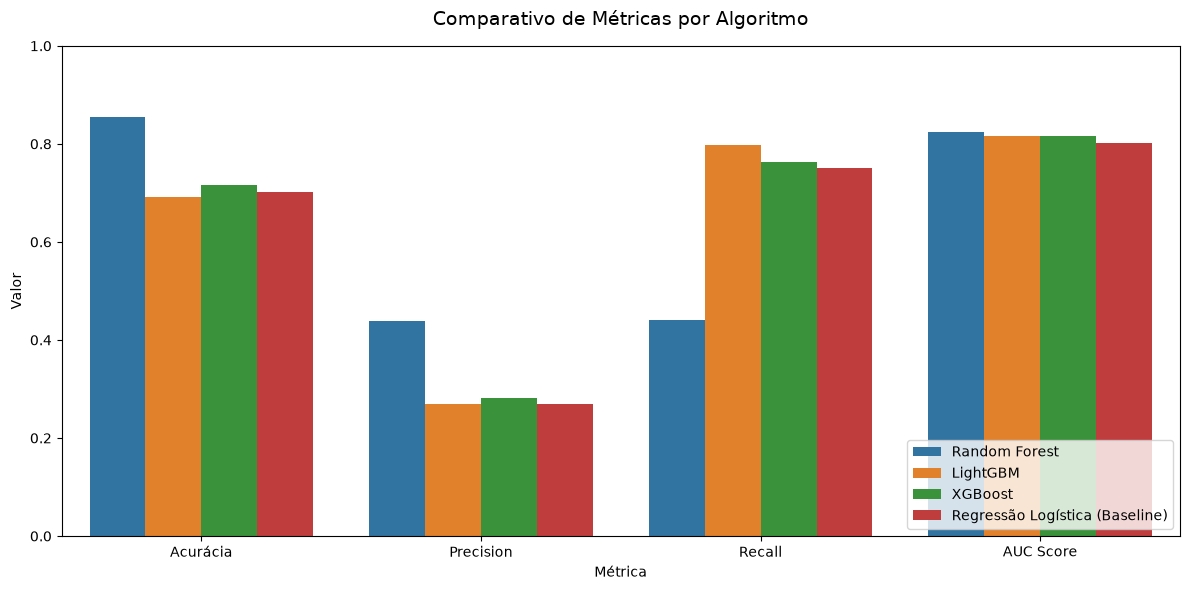

In [3]:
metricas = ['Acurácia', 'Precision', 'Recall', 'AUC Score']

df_plot = df_comparativo.melt(id_vars='Algoritmo', value_vars=metricas, var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Algoritmo')
plt.title('Comparativo de Métricas por Algoritmo', fontsize=14, pad=15)
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 4. Tempo de Treinamento

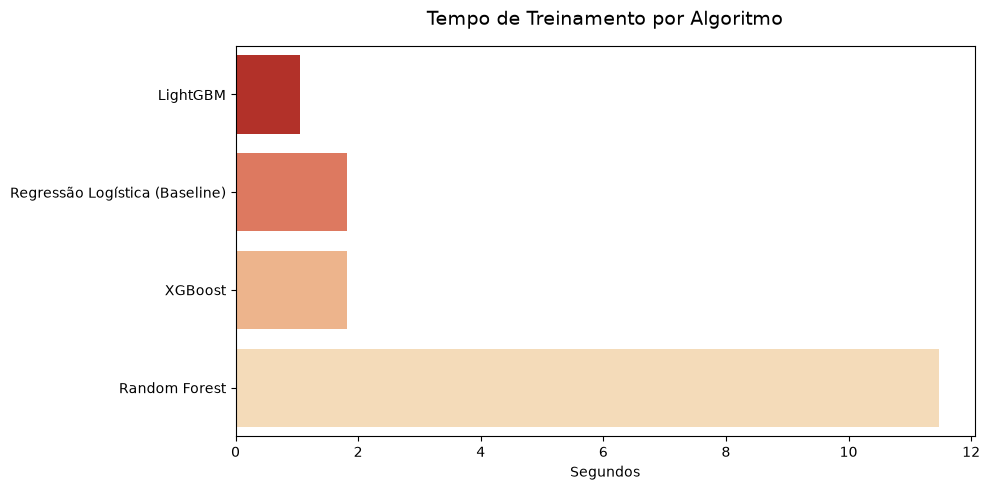

In [4]:
plt.figure(figsize=(10, 5))
ordenado_tempo = df_comparativo.sort_values(by='Tempo (segundos)')
sns.barplot(data=ordenado_tempo, x='Tempo (segundos)', y='Algoritmo', palette='OrRd_r')
plt.title('Tempo de Treinamento por Algoritmo', fontsize=14, pad=15)
plt.xlabel('Segundos')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 5. Curvas ROC de Todos os Modelos

Os modelos treinados são recarregados dos arquivos `.pkl` e reavaliados sobre o mesmo `X_test` (gerado por `preparar_dados.carregar_dados`), garantindo uma comparação de ROC em condições idênticas.

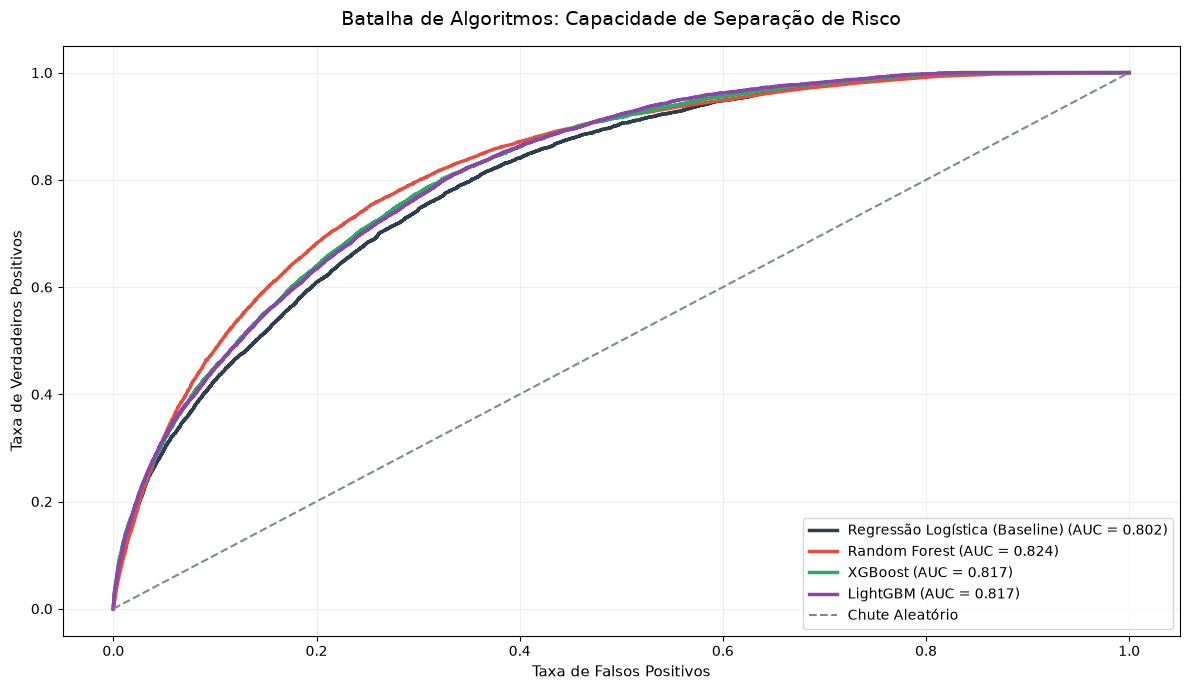

In [5]:
X_train, X_test, y_train, y_test = carregar_dados()

chaves_para_arquivos = {
    'Regressão Logística (Baseline)': '../models/modelo_regressao_logistica.pkl',
    'Random Forest': '../models/modelo_random_forest.pkl',
    'XGBoost': '../models/modelo_xgboost.pkl',
    'LightGBM': '../models/modelo_lightgbm.pkl',
}

plt.figure(figsize=(12, 7))
cores = ['#2c3e50', '#e74c3c', '#27ae60', '#8e44ad']

for (nome, caminho), cor in zip(chaves_para_arquivos.items(), cores):
    modelo = joblib.load(caminho)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_modelo = df_comparativo.loc[df_comparativo['Algoritmo'] == nome, 'AUC Score']
    auc_valor = float(auc_modelo.iloc[0]) if not auc_modelo.empty else float('nan')
    plt.plot(fpr, tpr, color=cor, lw=2.5, label=f"{nome} (AUC = {auc_valor:.3f})")

plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Chute Aleatório')
plt.title('Batalha de Algoritmos: Capacidade de Separação de Risco', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 6. Conclusão

- **AUC Score** é a métrica mais robusta aqui porque o dataset é desbalanceado (~13% de casos graves/fatais); ela mede a capacidade do modelo de separar as classes independente do limiar de decisão.
- **Recall** da classe grave/fatal importa tanto quanto Acurácia neste problema: um modelo que erra a Acurácia mas captura a maioria dos casos graves pode ser preferível para um sistema de alerta de risco.
- **Tempo de treinamento** pesa se o modelo for retreinado com frequência (ex: mensalmente, conforme novos dados da PRF chegam); é menos relevante se o modelo for treinado uma vez e apenas usado para inferência.
- **Nota metodológica:** cada linha do dataset representa uma pessoa envolvida em um acidente (não o acidente em si); acidentes com múltiplos envolvidos geram múltiplas linhas com as mesmas condições de via/clima. O split treino/teste é aleatório por linha, não agrupado por acidente. Como as features usadas são categorias amplas (não identificadores exclusivos do acidente), o risco de vazamento é baixo, mas uma validação futura com `GroupShuffleSplit` (agrupando por acidente) daria uma estimativa de generalização ainda mais rigorosa.